# Exploratory Data Analysis (EDA)

## Project

**Behavioural Risk Scoring Framework for Financial Transactions using Anomaly Detection**

## Objective

The objective of this analysis is to explore transaction-level data in order to identify behavioural patterns that distinguish normal and fraudulent activity.

This exploratory analysis aims to:

- Characterize the distribution and structural properties of financial transactions  
- Identify behavioural differences between legitimate and fraudulent operations  
- Detect patterns that can be leveraged for anomaly detection  
- Derive insights to support feature engineering and risk scoring model design  


## 1. Dataset Description

The dataset used in this study is the **PaySim dataset**, a synthetic dataset generated using a simulator that models real-world financial transaction behaviour based on mobile money transfer services.

PaySim is designed to replicate realistic transaction patterns, including both legitimate and fraudulent activities, making it suitable for fraud detection research while avoiding privacy concerns associated with real financial data.

Each record represents a financial transaction between two accounts and includes information about transaction value, account balances, transaction type, and fraud labels. The main variables are defined as follows:

- **amount**: Monetary value of the transaction.
- **type**: Categorical variable indicating the type of transaction (e.g., PAYMENT, TRANSFER, CASH_OUT, CASH_IN, DEBIT).
- **oldbalanceOrg**: Balance of the sender’s account before the transaction.
- **newbalanceOrig**: Balance of the sender’s account after the transaction.
- **oldbalanceDest**: Balance of the recipient’s account before the transaction.
- **newbalanceDest**: Balance of the recipient’s account after the transaction.
- **isFraud**: Binary indicator of whether the transaction is fraudulent (1) or legitimate (0).
- **step**: Time step of the transaction, representing a unit of time in the simulation (e.g., hours).
- **nameOrig**: Identifier of the sender account.
- **nameDest**: Identifier of the recipient account.
- **isFlaggedFraud**: Indicator of whether the transaction was flagged as fraudulent by a rule-based detection system.
- **balance_diff**: Derived feature representing the difference between expected and actual post-transaction balance for the sender account.

### Data Characteristics

The dataset exhibits several important characteristics:

- **Synthetic but realistic**: Although simulated, the data reflects realistic financial behaviour patterns.
- **Large scale**: The dataset contains millions of transactions, requiring efficient analysis and visualization techniques.
- **Class imbalance**: Fraudulent transactions represent a very small fraction of the data, making detection challenging.
- **Highly skewed distributions**: Transaction amounts are not normally distributed; most transactions are small, with a long tail of high-value transactions.
- **Behavioural structure**: Financial transactions follow balance consistency rules, which can be exploited to detect anomalies.

### Analytical Relevance

The structure of the PaySim dataset is particularly suitable for behavioural fraud detection, as it provides detailed information about transaction flows and account balance dynamics. These characteristics enable the analysis of transactional consistency, behavioural patterns, and structural relationships between variables.
In particular, the availability of pre- and post-transaction account balances allows for the derivation of features that capture deviations from expected financial behaviour, which are central to anomaly detection approaches.

### Limitations of the Dataset

As a synthetic dataset, PaySim has some limitations:

- It may not capture all complexities of real-world financial systems.
- Fraud patterns are simulated and may differ from real fraud strategies.
- Certain behaviours, particularly fraudulent transactions, may appear more structured than in real-world data due to the simulation process, potentially leading to patterns that are more regular than those observed in real financial systems.

These limitations must be considered when interpreting results and evaluating model performance.

### Objective of this Analysis

The primary objective of this exploratory data analysis (EDA) is to identify behavioural patterns that distinguish normal from fraudulent transactions. In particular, the analysis focuses on:

- Understanding the distribution of transaction amounts
- Identifying differences in behaviour across transaction types
- Evaluating balance consistency before and after transactions
- Detecting structural patterns that may indicate anomalous activity

The insights obtained from this analysis will guide the design of feature engineering strategies and the development of an anomaly detection model, forming the foundation for the subsequent design of the behavioural risk scoring framework and anomaly detection model.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/marc/Desktop/UOC/TFM/Code/financial-fraud-anomaly-detection/data/raw/PS_20174392719_1491204439457_log.csv")

In [20]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
 11  balance_diff    float64
dtypes: float64(6), int64(3), str(3)
memory usage: 582.5 MB


### Dataset Structure

- The dataset contains approximately 6.3 million transactions.
- There are 11 variables, including numerical, categorical, and binary features.
- No missing values are observed across the dataset.

The presence of both numerical and categorical variables supports a mixed analytical approach, combining statistical analysis with behavioural segmentation.

In [19]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06,-2.123056e+04
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03,1.466433e+05
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.915268e+06
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00,1.015044e+04
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00,1.000000e+07


### Summary Statistics

- Transaction amounts exhibit a highly right-skewed distribution, with a small number of very large transactions dominating the upper range.
- The large gap between median and maximum values confirms the presence of extreme outliers.
- Balance-related variables also show significant dispersion, suggesting heterogeneous transaction behaviour.
- There is a significant scale disparity between transaction amounts and account balance variables, which may affect distance-based anomaly detection methods and requires appropriate scaling or transformation.
- Several balance variables exhibit a median of zero, suggesting that a large proportion of transactions involve accounts with low or zero initial balances, which may reflect specific transaction types or system-level behaviours.

These distributional properties may interact with fraud behaviour, as anomalous transactions are likely to deviate from typical balance and amount relationships.

### Implications

- Raw monetary values are unlikely to be normally distributed and will require transformation (e.g., logarithmic scaling).
- Outliers may play a critical role in anomaly detection and should not be removed without careful consideration.
- Significant differences in variable scales may impact distance-based models and require normalization or transformation.
- Several balance variables contain zero values, which may indicate either empty accounts or specific transaction types.
- This behaviour may influence balance consistency analysis and should be considered during feature engineering.

These observations establish the statistical and structural properties of the dataset, forming the basis for subsequent behavioural analysis and the identification of anomaly-relevant features.

## 2. Data Quality

We evaluate missing values, duplicates, and potential inconsistencies.

In [5]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check balance consistency
df['balance_error'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['balance_error'].describe()

count    6.362620e+06
mean    -2.010925e+05
std      6.066505e+05
min     -9.244552e+07
25%     -2.496411e+05
50%     -6.867726e+04
75%     -2.954230e+03
max      1.000000e-02
Name: balance_error, dtype: float64

### Balance Consistency

The balance error measures the difference between the expected and actual post-transaction balance of the sender account.

- The distribution of balance_error shows significant dispersion, with large negative values indicating inconsistencies between transaction amounts and balance updates.
- The presence of extreme values suggests that balance updates do not always strictly follow conservation rules.

### Interpretation

This behaviour may reflect:
- simulation artefacts in the dataset
- delayed or partial balance updates
- transaction-specific mechanisms

### Implications

- Balance consistency cannot be assumed to hold strictly across all transactions.
- However, deviations from expected balance behaviour may serve as a valuable signal for anomaly detection.

In [ ]:
(df['oldbalanceOrg'] == 0).mean()
(df['newbalanceOrig'] == 0).mean()

np.float64(0.5673081214971191)

### Zero Balance Behaviour

A large proportion (~56%) of transactions involve sender accounts with zero initial balance.

### Interpretation

This suggests:
- the presence of inactive or newly initialized accounts
- structural characteristics of the PaySim simulation
- potential grouping of transactions by account state

### Implications

- Balance-based features must be interpreted carefully, as zero values may dominate certain transaction types.
- Behavioural patterns may differ significantly between zero-balance and non-zero-balance accounts.

In [23]:
pd.crosstab(df['isFraud'], df['isFlaggedFraud'])

isFlaggedFraud,0,1
isFraud,,
0,6354407,0
1,8197,16


### Fraud Label Consistency

The dataset includes both 'isFraud' and 'isFlaggedFraud'. However, only a very small subset of fraudulent transactions are flagged.

### Interpretation

- The flagging mechanism captures only a limited portion of fraudulent activity.
- 'isFlaggedFraud' appears to represent a rule-based detection system with low recall.

### Implications

- 'isFlaggedFraud' is not a reliable indicator of fraud on its own.
- It may still be useful as an auxiliary feature, but should not be used as a primary label.

In [24]:
(df['amount'] < 0).sum()

np.int64(0)

### Summary

- The dataset is technically clean, with no missing values or duplicate records.
- However, balance-related variables exhibit significant inconsistencies and dispersion.
- A large proportion of transactions involve zero-balance accounts, indicating structural characteristics in the data.
- Fraud flag variables capture only a small subset of fraudulent activity.
- Overall, the dataset is suitable for analysis, but its behavioural structure requires careful interpretation.

## 3. Transaction Amount Behaviour

We analyze the distribution of transaction amounts to understand the scale and variability of financial activity, and to identify patterns that may differentiate normal and potentially fraudulent behaviour.

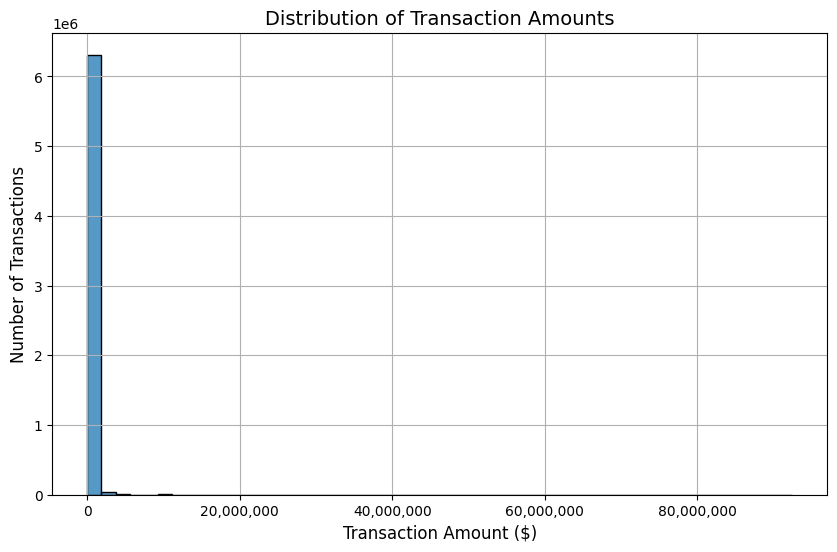

In [6]:
plt.figure(figsize=(10,6))
#With millions of transactions bins 50 is balanced for interpretaibility
sns.histplot(df['amount'], bins=50)
plt.title("Distribution of Transaction Amounts", fontsize=14)
plt.xlabel("Transaction Amount ($)", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)
#We format the output
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.grid(True)
plt.show()

### Observations (Raw Scale)

- The distribution of transaction amounts is highly right-skewed, with the vast majority of transactions concentrated at low values.
- A small number of transactions reach extremely high values, creating a long tail.
- This confirms the presence of heavy-tailed behaviour, which is typical in financial transaction data.

### Limitations

- The extreme skewness compresses most observations into a narrow region, making it difficult to visually distinguish patterns in the majority of transactions.

To address the strong skewness and improve interpretability, a logarithmic transformation is applied to the transaction amounts.

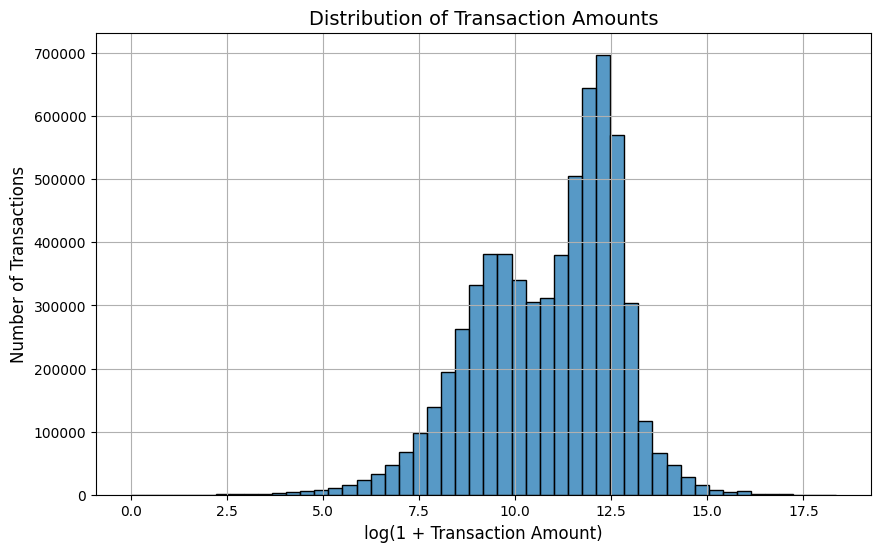

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df['amount']), bins=50)
plt.title("Distribution of Transaction Amounts", fontsize=14)
plt.xlabel("log(1 + Transaction Amount)", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)
plt.grid(True)
plt.show()

### Observations (Log Scale)

- After logarithmic transformation, the distribution becomes more symmetric and structured.
- The majority of transactions now form a clear central mass, revealing underlying patterns that were not visible in the raw scale.
- The presence of multiple peaks suggests potential segmentation in transaction behaviour, possibly associated with different transaction types or user groups.

### Implications

- Log transformation is necessary for meaningful statistical analysis and modelling.
- The structured distribution indicates that transaction amounts may contain behavioural signals useful for anomaly detection.

### Fraud vs Non-Fraud Comparison

To understand whether transaction amounts differ between normal and fraudulent transactions, we compare their distributions.

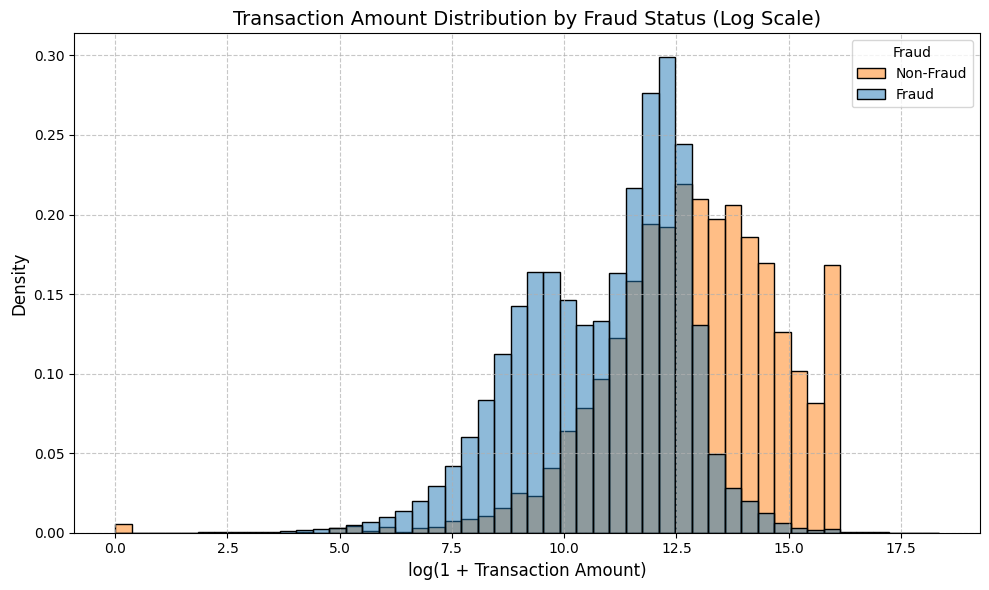

In [26]:
# Plot distribution of transaction amounts for fraud vs non-fraud (log scale)
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x=np.log1p(df['amount']),       # Log transformation to reduce skewness
    hue='isFraud',                  # Separate distributions by fraud status
    bins=50,
    stat='density',                 # Normalize for comparison
    common_norm=False,              # Each group has its own normalization
    alpha=0.5
)

# Titles and labels
plt.title("Transaction Amount Distribution by Fraud Status (Log Scale)", fontsize=14)
plt.xlabel("log(1 + Transaction Amount)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Improve readability
plt.grid(True, linestyle='--', alpha=0.7)

plt.legend(title="Fraud", labels=["Non-Fraud", "Fraud"])

plt.tight_layout()
plt.show()

### Behavioural Insight

The distribution of transaction amounts differs noticeably between normal and fraudulent transactions.

- Fraudulent transactions are shifted towards higher values, indicating that fraud tends to involve larger monetary amounts.
- Normal transactions are more concentrated in lower and mid-range values, with a wider spread.
- Despite this separation, there is still overlap between the two distributions, indicating that transaction amount alone is not sufficient to fully distinguish fraud.

### Implications

- Transaction amount is a strong but not definitive indicator of fraudulent behaviour.
- Higher-value transactions are more likely to be associated with fraud, but legitimate transactions can also occur at similar scales.
- This suggests that transaction amount should be combined with other behavioural features, such as balance consistency and transaction type, to improve detection performance.

In [27]:
# Compare mean and median transaction amount by fraud status
df.groupby('isFraud')['amount'].agg(['mean', 'median', 'std'])

,mean,median,std
isFraud,,,
0,1.781970e+05,74684.72,5.962370e+05
1,1.467967e+06,441423.44,2.404253e+06


### Quantitative Comparison

A clear distinction is observed between normal and fraudulent transactions in terms of monetary value.

- The average transaction amount for fraudulent transactions (~1.46M) is significantly higher than for normal transactions (~0.18M), indicating that fraud tends to involve substantially larger sums.
- The median values further confirm this pattern, with fraudulent transactions (~441k) consistently exceeding normal transactions (~74k), suggesting that this behaviour is not driven solely by extreme outliers.
- Fraudulent transactions also exhibit much higher variability, as reflected by the larger standard deviation, indicating more dispersed and less predictable behaviour.

### Interpretation

These results suggest that fraudulent activity is systematically associated with higher transaction magnitudes, reinforcing the importance of transaction amount as a key behavioural feature for fraud detection.

### Risk Perspective

From a financial risk standpoint, the significantly higher magnitude of fraudulent transactions suggests that attackers aim to maximize monetary impact per event. 

However, despite this clear difference in central tendency, the overlap between distributions indicates that high-value transactions cannot be considered inherently fraudulent, highlighting the need for multi-dimensional risk assessment approaches.

In [30]:
# Create quantile-based bins for transaction amounts (equal number of observations per bin)
df['amount_bin'] = pd.qcut(df['amount'], q=5)

# Compute fraud rate within each bin
fraud_rate = df.groupby('amount_bin')['isFraud'].mean()

fraud_rate

amount_bin
(-0.001, 9866.158]          0.000217
(9866.158, 36371.35]        0.000403
(36371.35, 122563.784]      0.000950
(122563.784, 246611.22]     0.000852
(246611.22, 92445516.64]    0.004032
Name: isFraud, dtype: float64

### Risk by Transaction Size

To assess how fraud risk varies with transaction magnitude, transactions were grouped into quantile-based bins, and the fraud rate was computed for each group.

- Fraud probability increases with transaction amount, with the highest-value transactions exhibiting a significantly higher fraud rate.
- The lowest-value transactions show minimal fraud incidence, while the highest bin reaches approximately 0.40%, representing a substantial increase in risk.
- The relationship is not strictly monotonic, suggesting that fraud behaviour is influenced by additional factors beyond transaction magnitude.

### Interpretation

These results indicate that transaction amount is a strong risk indicator, but not sufficient on its own to fully explain fraudulent behaviour.

### Implications

- Transaction amount can be used as a key feature in behavioural risk scoring.
- However, it should be combined with other variables such as transaction type and balance consistency to improve predictive performance.

### Business Perspective

From a financial risk management standpoint, higher-value transactions represent greater potential losses and therefore warrant increased scrutiny.

The observed increase in fraud rate across transaction sizes supports the use of risk-based thresholds and prioritization strategies, where higher-value transactions are subject to more rigorous monitoring or additional verification steps.

## 4. Transaction Type Distribution

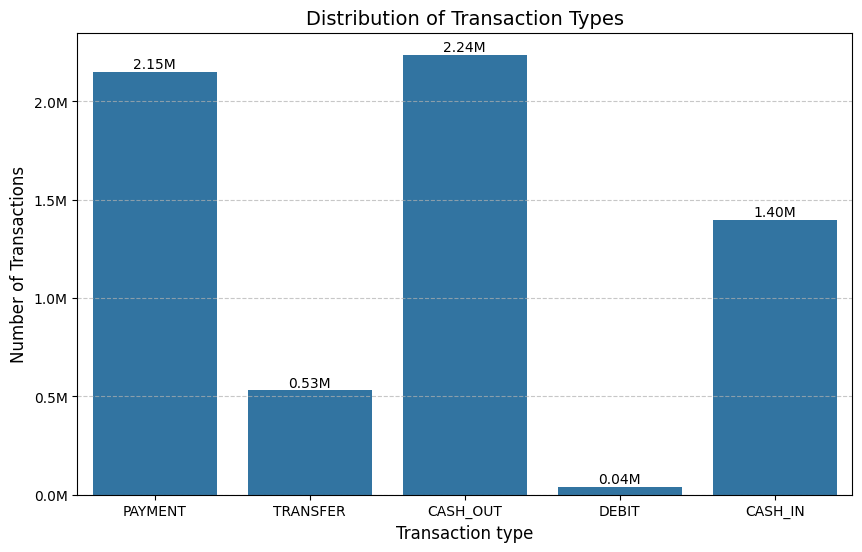

In [8]:
#Transaction types
df['type'].value_counts()
plt.figure(figsize=(10,6))

ax = sns.countplot(x='type', data=df)

plt.title("Distribution of Transaction Types", fontsize=14)
plt.xlabel("Transaction type", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)

#Format y-axis
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

#We have less bars now so we can add values on the top for interpretability
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height/1e6:.2f}M', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Observations

- CASH_OUT and PAYMENT transactions dominate the dataset, representing the majority of financial activity.
- TRANSFER transactions are less frequent but still significant.
- DEBIT transactions are rare, indicating limited usage in the simulated environment.

### Interpretation

The distribution reflects typical financial system behaviour, where certain transaction types (e.g., payments and cash withdrawals) occur more frequently than others.

In [31]:
# Compute fraud rate by transaction type
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)

fraud_by_type

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

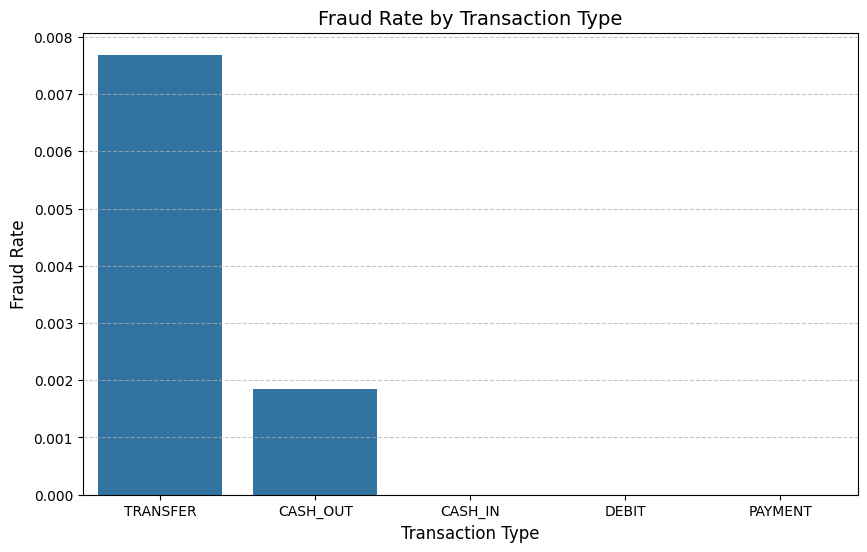

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=fraud_by_type.index,
    y=fraud_by_type.values
)

plt.title("Fraud Rate by Transaction Type", fontsize=14)
plt.xlabel("Transaction Type", fontsize=12)
plt.ylabel("Fraud Rate", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Fraud Behaviour by Transaction Type

Fraudulent activity is highly concentrated in specific transaction types.

- Fraud occurs exclusively in TRANSFER and CASH_OUT transactions.
- TRANSFER transactions exhibit the highest fraud rate (~0.77%), making them the most risky operation type.
- CASH_OUT transactions also present elevated risk (~0.18%), although significantly lower than TRANSFER.
- PAYMENT, CASH_IN, and DEBIT transactions show no fraudulent activity in the dataset.

### Interpretation

This indicates that fraudulent behaviour is not randomly distributed across transaction types, but is structurally linked to operations that enable direct transfer or extraction of funds.

### Risk Implications

- TRANSFER transactions represent the highest-risk channel and should be subject to enhanced monitoring.
- CASH_OUT transactions also require scrutiny due to their role in fund extraction.
- Other transaction types may serve as lower-risk baseline behaviour.

### Key Insight

Transaction type is a stronger discriminator of fraud than transaction amount, as it directly reflects the operational mechanisms exploited by fraudulent actors.

In [33]:
pd.crosstab(df['type'], df['isFraud'], normalize='index')

isFraud,0,1
type,,
CASH_IN,1.000000,0.000000
CASH_OUT,0.998160,0.001840
DEBIT,1.000000,0.000000
PAYMENT,1.000000,0.000000
TRANSFER,0.992312,0.007688


## 5. Fraud profile and class imbalance

This section characterizes fraud from two complementary perspectives:

1. **Incidence**: how rare fraudulent transactions are in the dataset  
2. **Profile**: how fraudulent transactions differ from legitimate ones in terms of transaction magnitude

In [39]:
# -------------------------------------------------------------
# Compute the relative frequency of fraudulent and legitimate
# transactions in order to assess class imbalance.
# -------------------------------------------------------------
fraud_distribution = df['isFraud'].value_counts(normalize=True)

# Display class proportions
fraud_distribution

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

### Class Imbalance

Fraudulent transactions represent approximately **0.13%** of the dataset, confirming that fraud is an extremely rare event.

### Implications

- The dataset is highly imbalanced, making standard accuracy an unsuitable evaluation metric.
- This class distribution supports the use of anomaly detection and risk-based ranking approaches.
- Fraud detection should focus on identifying rare but high-impact behavioural deviations rather than optimizing overall classification accuracy.

In [40]:
# -------------------------------------------------------------
# Compare transaction amount statistics by fraud status.
# This provides a quantitative summary of how transaction
# magnitude differs between legitimate and fraudulent activity.
# -------------------------------------------------------------
amount_by_fraud = df.groupby('isFraud')['amount'].agg(['mean', 'median', 'std'])

# Display summary statistics by class
amount_by_fraud

,mean,median,std
isFraud,,,
0,1.781970e+05,74684.72,5.962370e+05
1,1.467967e+06,441423.44,2.404253e+06


### Quantitative Fraud Profile

The average and median transaction amounts are substantially higher for fraudulent transactions than for legitimate ones.

This indicates that fraud is not only rare, but also economically more severe on average, involving larger monetary values per event.

### Interpretation

- Fraudulent transactions have a much higher **mean** amount, indicating greater average monetary impact.
- Fraudulent transactions also have a much higher **median** amount, showing that this difference is not driven only by a few extreme outliers.
- The larger standard deviation for fraud suggests greater variability in fraudulent transaction magnitude.

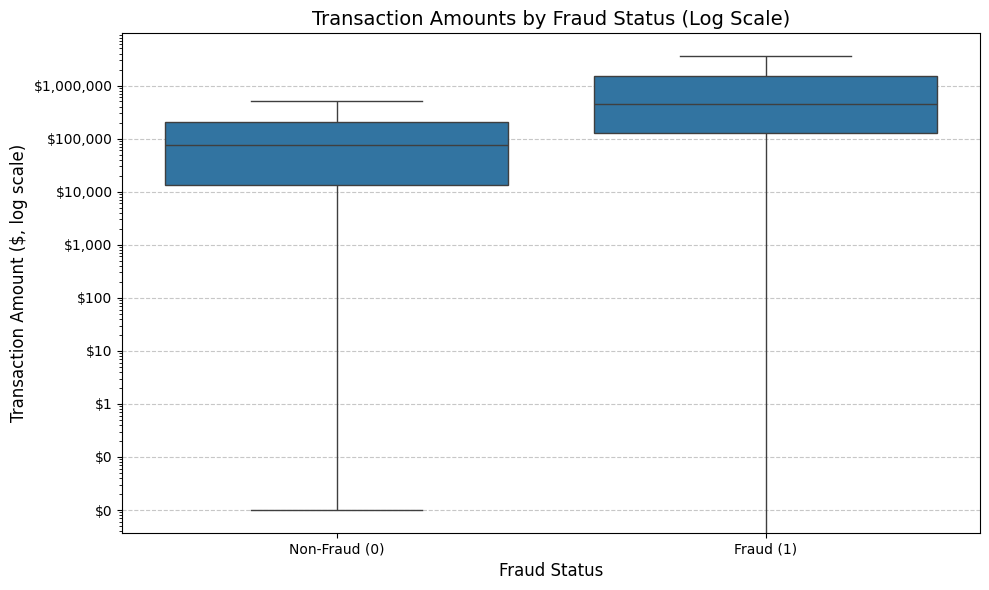

In [41]:
# -------------------------------------------------------------
# Plot transaction amount by fraud status.
# The purpose of this visualization is to characterize the
# monetary profile of fraud, not to repeat the general amount
# distribution analysis from Section 3.
#
# A logarithmic scale is applied because transaction amounts
# are highly right-skewed and span several orders of magnitude.
# Outliers are hidden to improve readability of the central
# distribution.
# -------------------------------------------------------------
plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df,
    x='isFraud',
    y='amount',
    showfliers=False
)

# Apply logarithmic scaling to improve interpretability
plt.yscale('log')

# Titles and labels
plt.title("Transaction Amounts by Fraud Status (Log Scale)", fontsize=14)
plt.xlabel("Fraud Status", fontsize=12)
plt.ylabel("Transaction Amount ($, log scale)", fontsize=12)

# Replace binary labels with readable class names
plt.xticks([0, 1], ["Non-Fraud (0)", "Fraud (1)"])

# Format y-axis as currency
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

# Add horizontal grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout and display plot
plt.tight_layout()
plt.show()

### Transaction Amount by Fraud Status

The boxplot shows a clear upward shift in transaction amounts for fraudulent operations relative to legitimate ones.

- Fraudulent transactions have a substantially higher median transaction amount.
- The interquartile range for fraud is also located at higher values, indicating a systematic difference rather than an effect driven only by extreme values.
- Nevertheless, overlap remains between the two groups, indicating that transaction amount alone cannot fully separate fraud from legitimate behaviour.

### Risk Interpretation

From a financial risk perspective, this indicates that fraudulent operations tend to concentrate in higher-value ranges, increasing the expected loss per event.

However, the observed overlap between classes implies that effective fraud detection cannot rely on transaction amount alone. Instead, transaction amount should be combined with other behavioural signals such as transaction type, balance consistency, and temporal structure.

### Methodological Implication

The combination of **extreme rarity** and **higher monetary impact** makes fraud a particularly challenging detection problem.

This supports the use of anomaly detection methods and behavioural risk scoring frameworks, which are better suited to identifying rare and atypical transaction patterns than approaches that assume balanced class distributions.

### Conclusion

Fraud in the PaySim dataset is characterized by two key properties:

1. It is **extremely rare**
2. It tends to involve **larger transaction amounts**

These findings reinforce the need for a detection framework that prioritizes rare but high-impact events and combines multiple behavioural features rather than relying on transaction magnitude in isolation.

## 6. Behavioural Differences: Fraud vs Normal

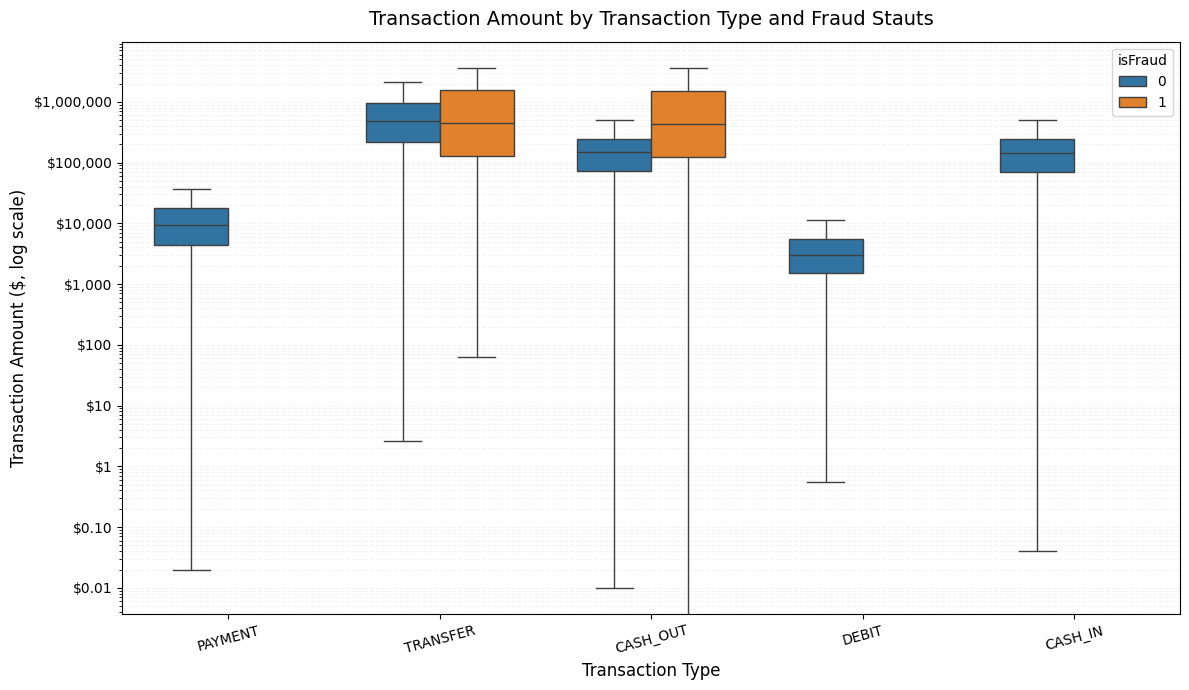

In [44]:
plt.figure(figsize=(12,7))

ax = sns.boxplot(
    data=df, 
    x='type', 
    y='amount', 
    hue='isFraud', 
    showfliers=False, 
    width=0.7)

ax.set_yscale('log')

ax.set_title("Transaction Amount by Transaction Type and Fraud Stauts", fontsize=14, pad=12)
ax.set_xlabel("Transaction Type", fontsize=12)
ax.set_ylabel("Transaction Amount ($, log scale)", fontsize=12)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x:,.0f}" if x >= 1 else f"${x:.2f}")
)

ax.grid(True, axis="y", which="both", linestyle="--", alpha=0.15)
ax.legend(title="isFraud")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Behavioural Differences Across Transaction Types

This analysis examines how transaction amounts differ between fraudulent and legitimate operations across transaction types.

### Key Observations

- Fraudulent activity is observed only in TRANSFER and CASH_OUT transaction types.
- Within these transaction types, fraudulent transactions exhibit consistently higher transaction amounts compared to legitimate ones.
- Other transaction types (PAYMENT, CASH_IN, DEBIT) show no fraudulent activity, reinforcing their role as low-risk operations.

### Interpretation

The results indicate that fraud is not only associated with specific transaction types, but also exhibits distinct magnitude patterns within those types.

This suggests that fraudulent behaviour is **conditional**, depending on both the nature of the transaction and its monetary value.

### Risk Interpretation

From a financial risk perspective, this behaviour suggests that fraudsters strategically exploit specific transaction mechanisms (TRANSFER and CASH_OUT) and operate at higher transaction values within those channels.

This reinforces the need for **conditional risk modelling**, where risk is assessed based on combinations of features (e.g., transaction type and amount), rather than treating each variable independently.

### Implication for Risk Scoring

These findings support the design of a behavioural risk scoring framework that captures interactions between transaction features, particularly:

- Transaction type (structural risk)
- Transaction amount (magnitude risk)

Such interactions are critical for accurately identifying anomalous behaviour in financial transactions.

## 7. Balance Consistency Analysis

We analyze whether account balance updates are consistent with transaction amounts.

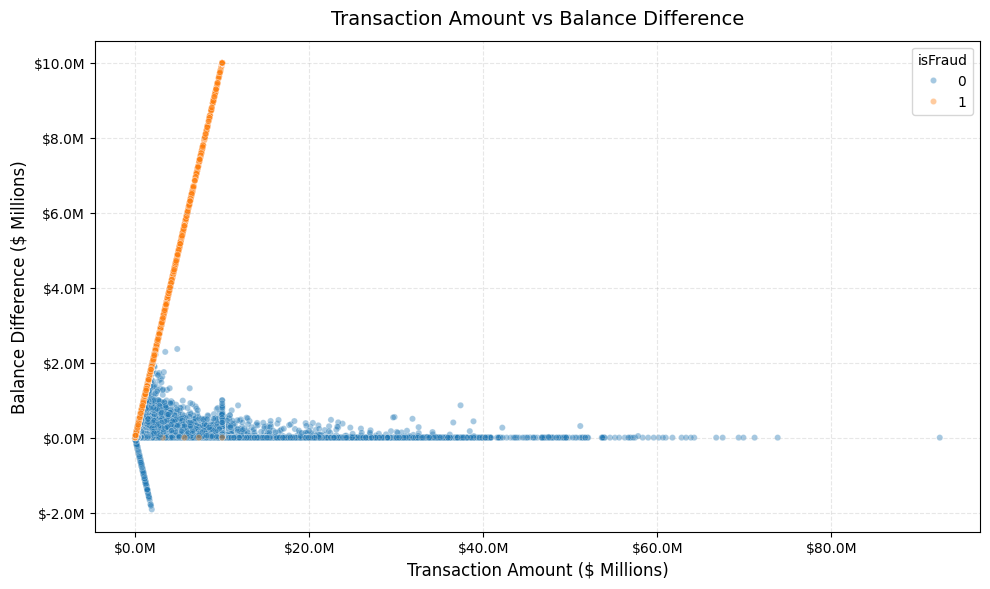

In [12]:
df['balance_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']

plt.figure(figsize=(10,6))

ax = sns.scatterplot(
    data=df, 
    x='amount', 
    y='balance_diff', 
    hue='isFraud', 
    alpha=0.4, 
    s=20)

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M")
)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, _: f"${y/1e6:.1f}M")
)

ax.set_title("Transaction Amount vs Balance Difference", fontsize=14, pad=12)
ax.set_xlabel("Transaction Amount ($ Millions)", fontsize=12)
ax.set_ylabel("Balance Difference ($ Millions)", fontsize=12)

ax.grid(True, linestyle='--', alpha=0.3)

plt.legend(title="isFraud", loc="upper right")

plt.tight_layout()
plt.show()

### Balance Consistency Principle

In a valid transaction, the sender’s balance should decrease by approximately the transaction amount:

oldbalanceOrg - amount ≈ newbalanceOrig

This implies that:

balance_diff ≈ amount

### Observations

- Fraudulent transactions align almost perfectly along the identity line (balance difference ≈ transaction amount).
- Legitimate transactions exhibit significant dispersion, deviating from this ideal relationship.

### Interpretation

The strong linear pattern observed in fraudulent transactions indicates a highly structured and deterministic behaviour.

In contrast, legitimate transactions show variability and inconsistencies, reflecting real-world complexity such as delays, rounding effects, or system-specific behaviour.

This suggests that fraud in the dataset follows simplified balance update rules, while normal transactions exhibit more heterogeneous dynamics.

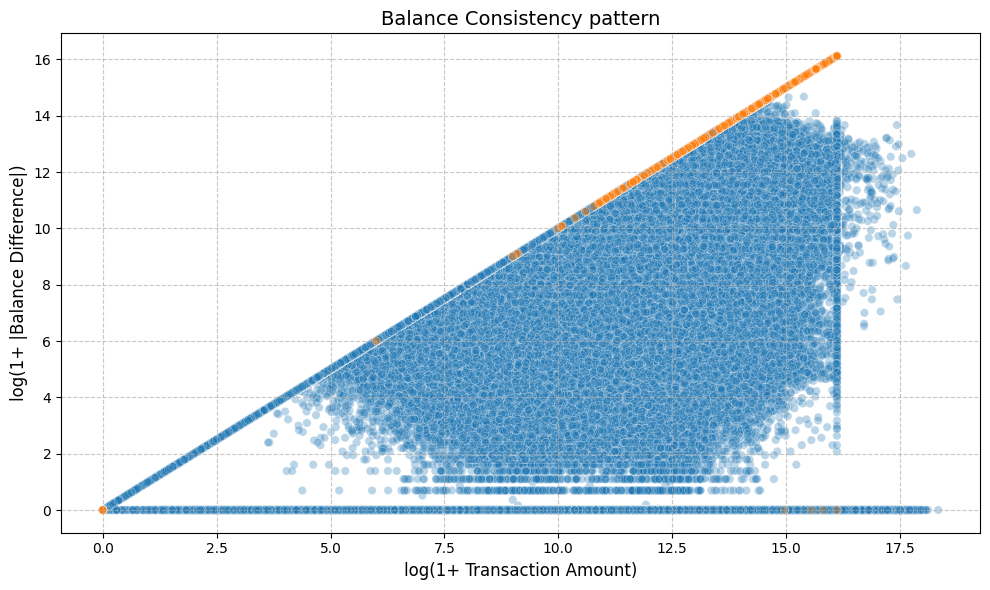

In [17]:
plt.figure(figsize=((10,6)))
sns.scatterplot(
    x=np.log1p(df['amount']),
    y=np.log1p(abs(df['balance_diff'])),
    hue='isFraud',
    data=df, 
    alpha=0.3, 
    legend=False #avoid slow legend warning
)
plt.title("Balance Consistency pattern", fontsize=14)
plt.xlabel("log(1+ Transaction Amount)", fontsize=12)
plt.ylabel("log(1+ |Balance Difference|)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Observations

- A clear triangular structure emerges after log transformation.
- The upper boundary corresponds to the theoretical constraint where balance difference equals transaction amount.
- Fraudulent transactions lie almost exclusively along this boundary.
- Legitimate transactions occupy the interior region, showing deviations from perfect balance consistency.

### Interpretation

The results reveal a fundamental behavioural difference between fraudulent and legitimate transactions.

Fraudulent transactions exhibit highly deterministic behaviour, strictly following balance constraints. In contrast, legitimate transactions display variability and dispersion, reflecting real-world financial dynamics.

This suggests that fraud in the dataset is characterised not by randomness, but by **overly consistent and structured patterns**.

### Risk and Modelling Implications

From a financial risk perspective, this behaviour indicates that fraudulent transactions may be engineered to satisfy strict balance constraints, potentially to bypass basic validation mechanisms.

However, this deterministic behaviour itself becomes a signal of abnormality, as real financial activity typically involves noise and variability.

This highlights the importance of detecting **structural anomalies**, not only extreme values. In particular, transactions that lie on the boundary of the feasible region may represent high-risk events.

These findings support the use of behavioural features that capture deviations from expected balance dynamics in anomaly detection models.

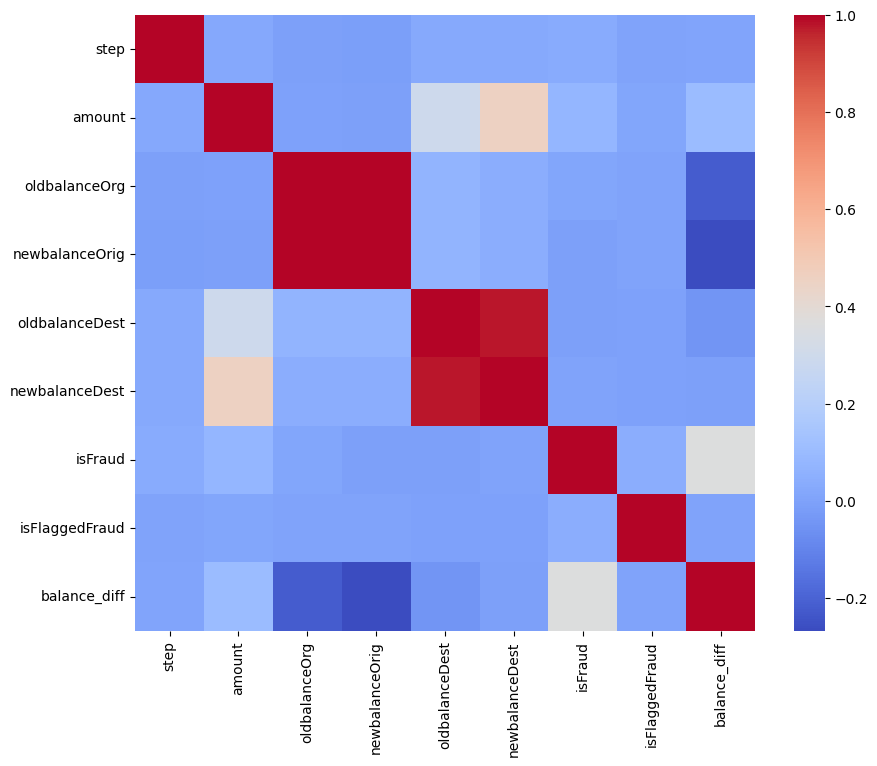

In [41]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

### Correlation Analysis

The correlation matrix highlights strong relationships between balance-related variables, reflecting expected accounting consistency (e.g., old and new balances).

However, the correlation between individual variables and the fraud label is weak across all features.

### Interpretation

This indicates that fraudulent behaviour cannot be explained by any single variable in isolation. Instead, fraud appears to depend on interactions between variables, such as transaction type, amount, and balance dynamics.

This reinforces the importance of behavioural and interaction-based features rather than relying on simple linear relationships.

### Feature Engineering Insights

Based on the behavioural patterns identified during the exploratory analysis, several feature candidates are proposed to capture anomaly signals.

#### Proposed Features

- **Balance Error**: captures deviations from expected balance updates  
- **Transaction Type Indicator**: highlights structurally risky operations  
- **Log-Scaled Amount**: stabilizes variance and captures magnitude  
- **Interaction Features**: combines transaction type and amount  
- **Consistency Metrics**: quantify adherence to accounting constraints  

#### Rationale

These features aim to capture structural and behavioural anomalies rather than relying on individual variables, aligning with the observed limitations of simple correlation-based approaches.

These features will be formally constructed and evaluated in the subsequent feature engineering stage.

## 9. Conclusions

### Key Findings

- Transaction amounts exhibit a highly right-skewed distribution, with a small number of high-value transactions dominating the upper range. This justifies the use of logarithmic transformations for analysis and modelling.

- Fraudulent activity is strongly concentrated in specific transaction types, particularly TRANSFER and CASH_OUT, indicating that fraud is structurally linked to certain financial operations.

- Fraudulent transactions tend to involve higher monetary values within these transaction types, suggesting increased financial exposure per event.

- Fraudulent behaviour is not driven by individual variables in isolation, but by interactions between features such as transaction type, amount, and balance dynamics.

- A clear behavioural distinction emerges in balance consistency: fraudulent transactions exhibit highly deterministic patterns, strictly following expected balance relationships, while legitimate transactions display variability and dispersion.

- This structural consistency places fraudulent transactions along the boundary of the feasible region, making them identifiable through deviation from typical behavioural patterns rather than extreme values alone.

### Implications for Modelling

These findings indicate that effective fraud detection requires a behavioural approach, focusing on feature interactions and structural anomalies rather than simple statistical relationships.

In particular, features capturing balance consistency, transaction type risk, and interaction effects are expected to play a critical role in anomaly detection and behavioural risk scoring models.

These insights will guide the feature engineering process and the design of the subsequent anomaly detection framework.